# Exercise: Clustering Algorithms with Scikit Learn

<img src="../IMG/sk-logo.png" width=200>

* ***SkLearn*** API Reference: https://scikit-learn.org/stable/modules/classes.html
* ***SkLearn*** Clustering Algorithms: https://scikit-learn.org/stable/modules/clustering.html#clustering

Hello students! The following is the initial task in the **Generative Computer Vision Models** module

In [8]:
#setup env
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler

In [9]:
#helper calls
n_samples = 1500
random_state = 170
X, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)

#generating Data Sets A-F
A = datasets.make_circles(n_samples=n_samples, factor=.5,noise=.05)[0]
B = datasets.make_moons(n_samples=n_samples, noise=.05)[0]
C = datasets.make_blobs(n_samples=n_samples, random_state=8)[0]
D = np.random.rand(n_samples, 2)
E = (X_aniso, y)[0]
F = datasets.make_blobs(n_samples=n_samples,
                             cluster_std=[1.0, 2.5, 0.5],
                             random_state=random_state)[0]

## Exercise 1
Plot all raw datasets A-F in one figure.

Hints: use ```scatter``` plots and ```subfigures```.

<Figure size 640x480 with 0 Axes>

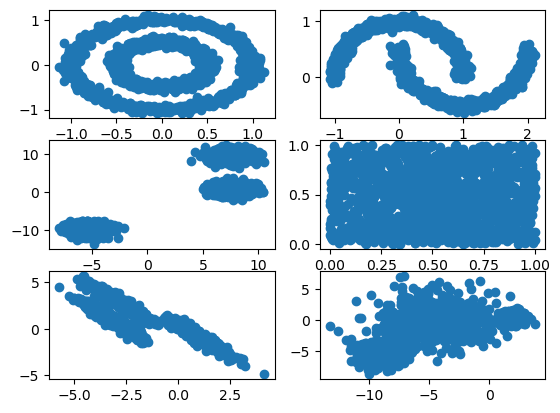

In [10]:
f = plt.figure()    
f, axes = plt.subplots(nrows = 3, ncols = 2)

axes[0][0].scatter(A[:,0],A[:,1])
axes[0][1].scatter(B[:,0],B[:,1])
axes[1][0].scatter(C[:,0],C[:,1])
axes[1][1].scatter(D[:,0],D[:,1])
axes[2][0].scatter(E[:,0],E[:,1])
axes[2][1].scatter(F[:,0],F[:,1])

## Exercise 2
Perform ```K-Means``` clustering on all data sets: https://scikit-learn.org/stable/modules/clustering.html#k-means
* 2.1 Plot all results
* 2.2 Manually try to find the best $k$ for each data set (by visual evaluation)
* 2.3 Use the ```K-Means++``` initialization 
* 2.4 Learn the optimal value of $k$ using the elbow method 

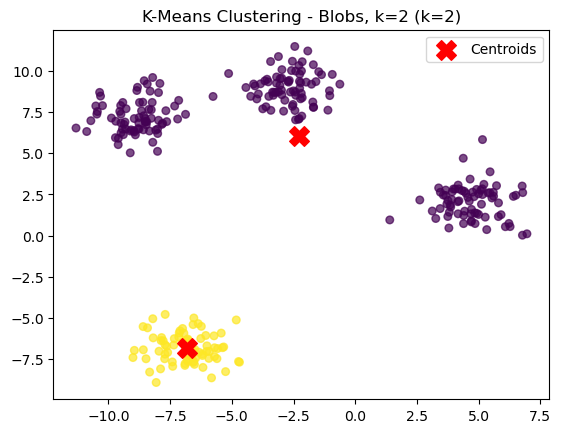

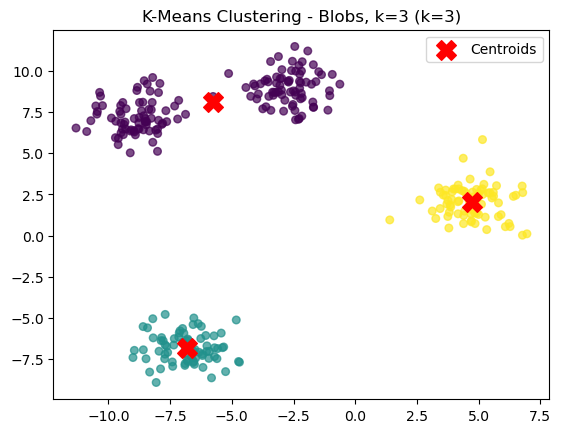

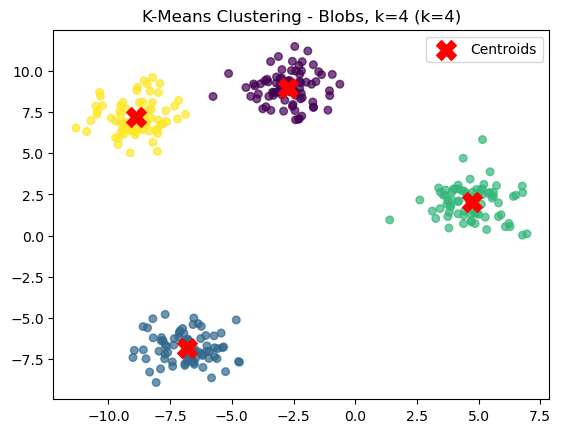

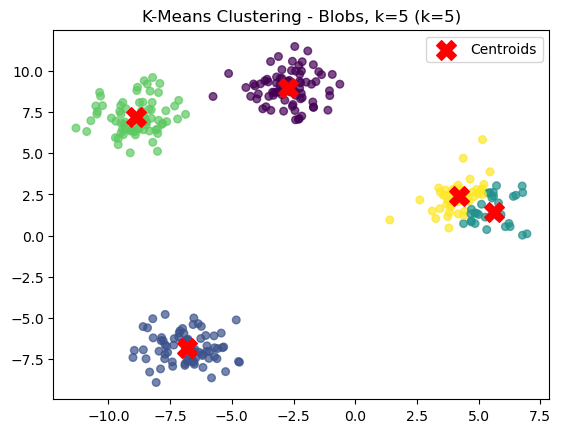

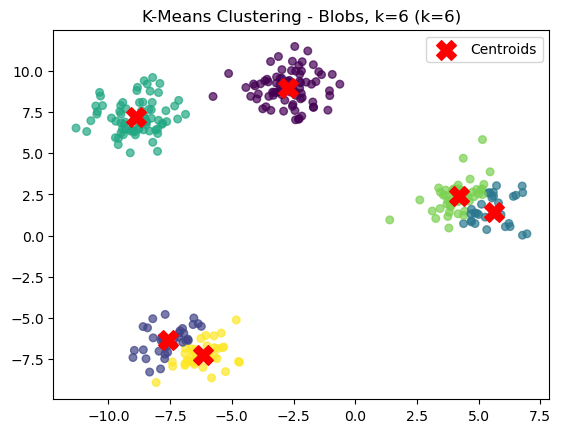

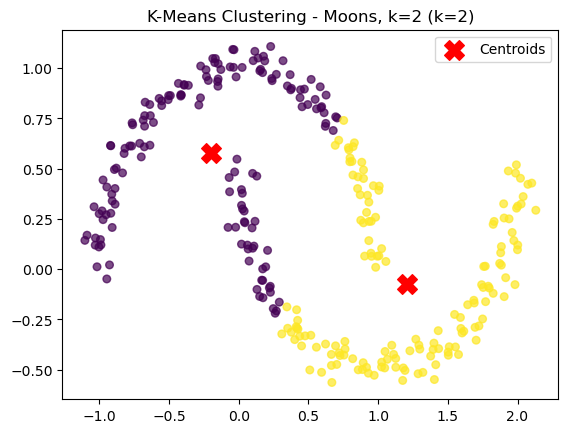

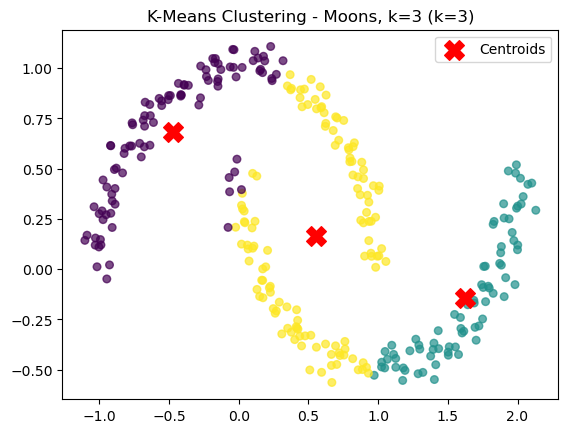

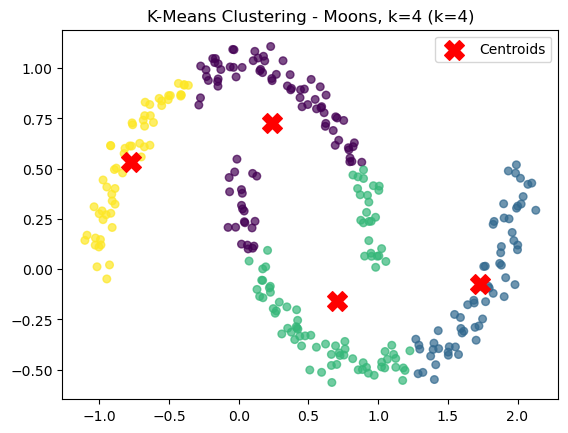

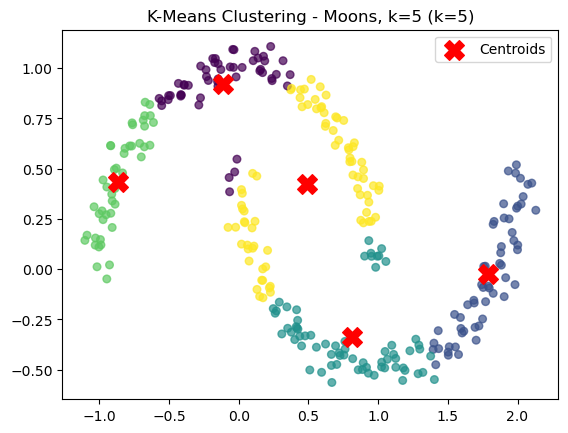

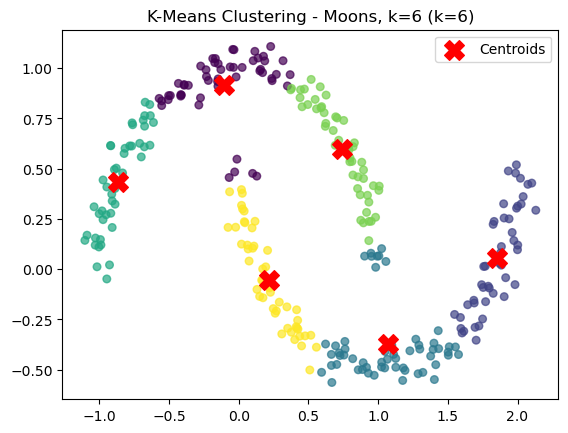

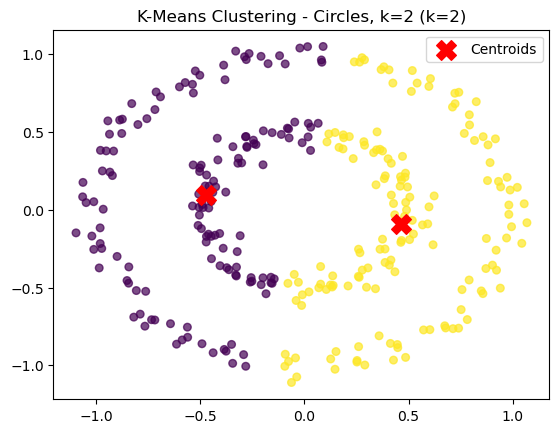

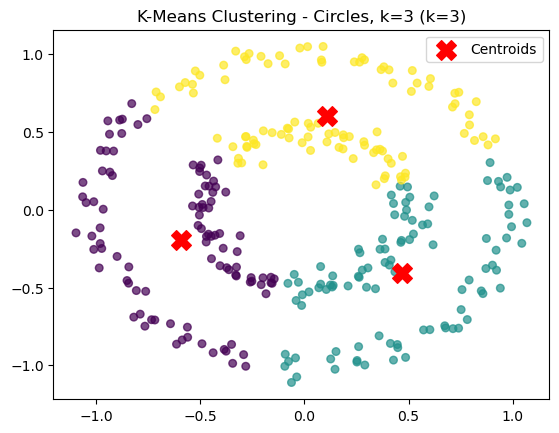

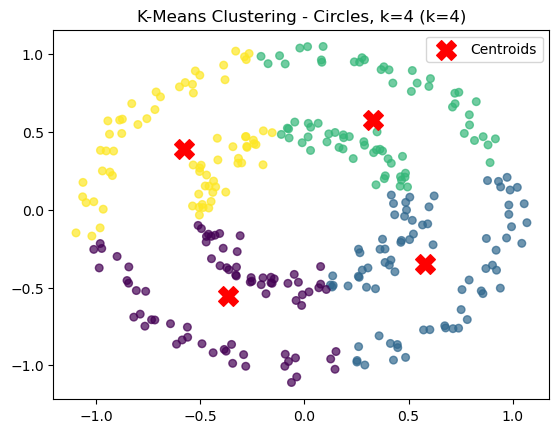

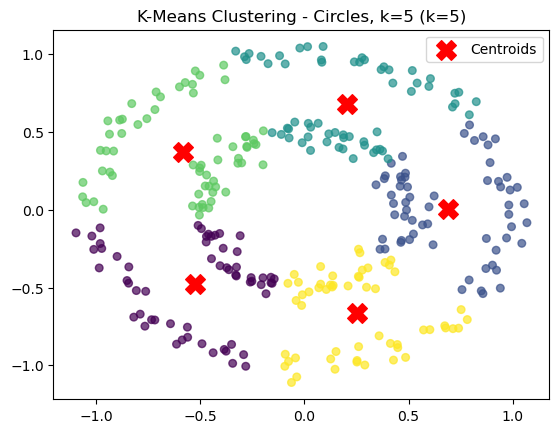

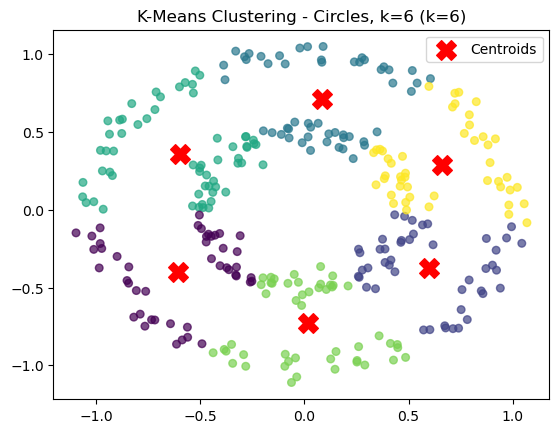

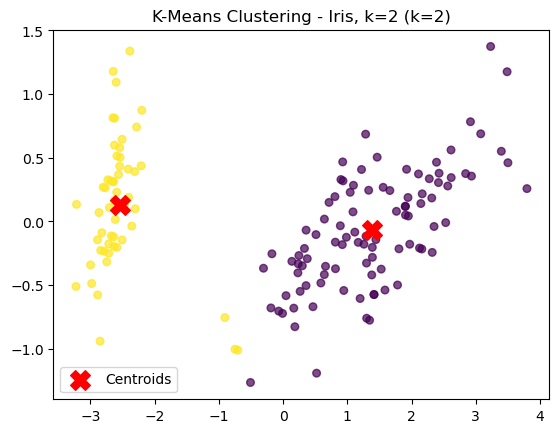

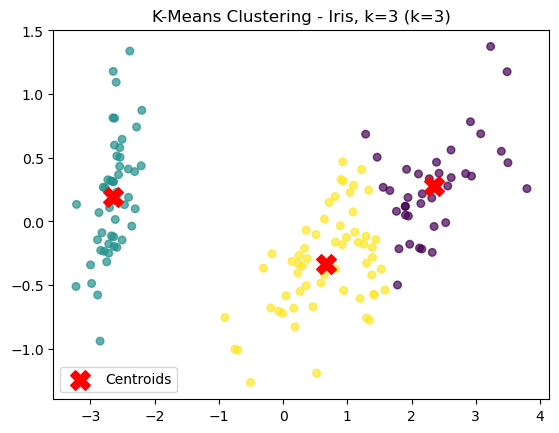

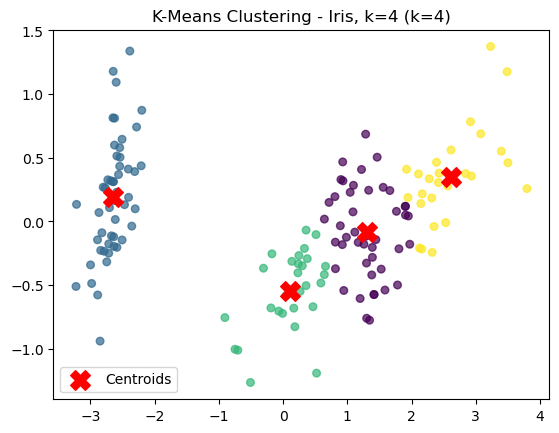

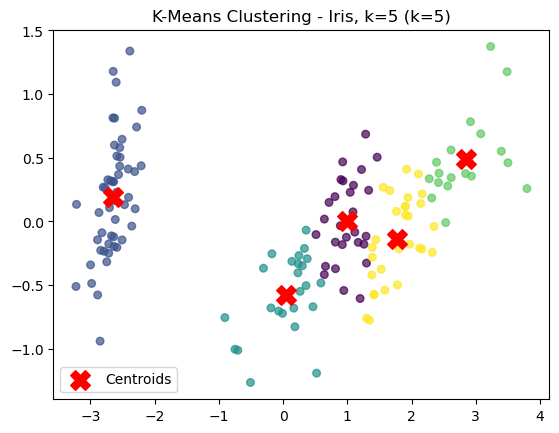

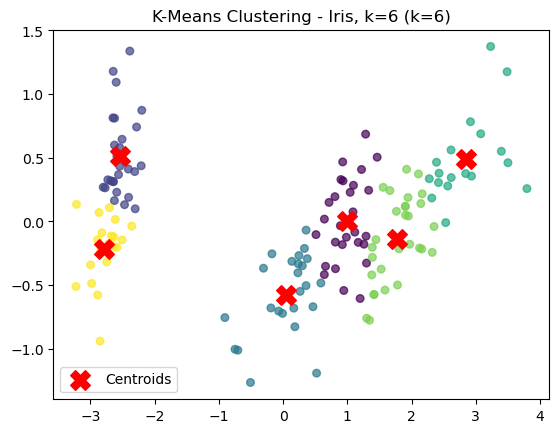

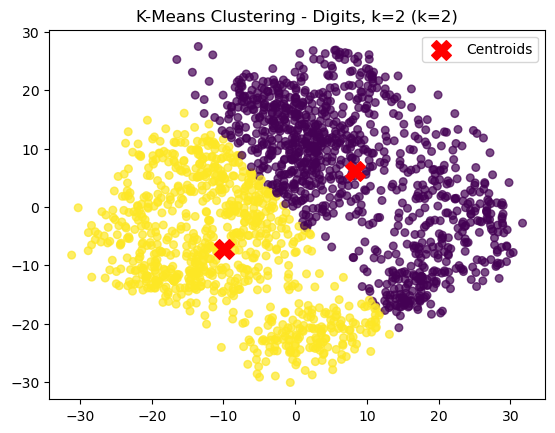

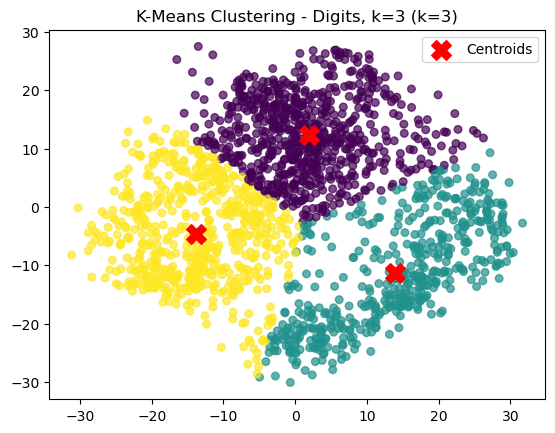

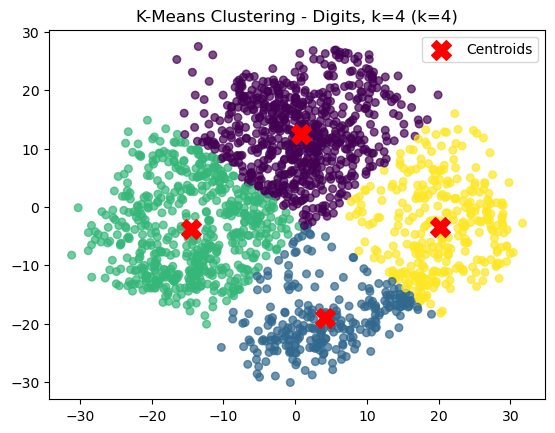

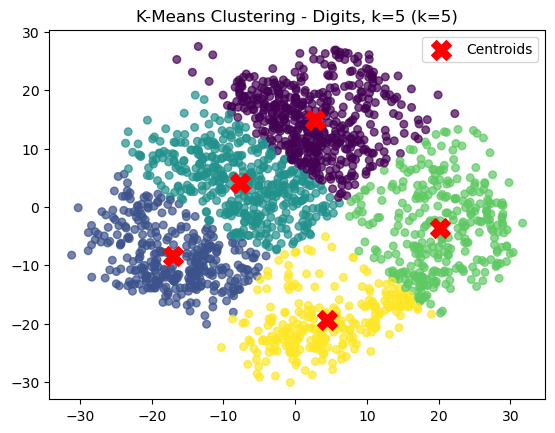

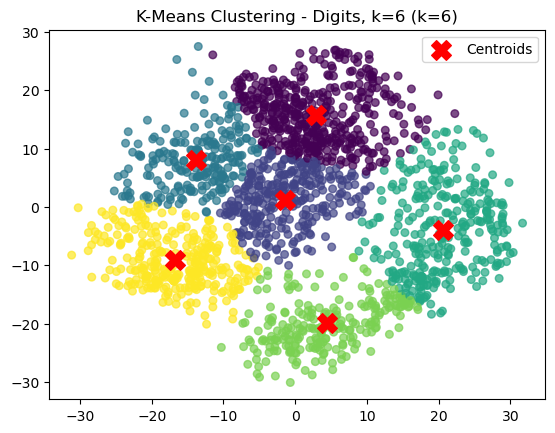

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_blobs, make_moons, make_circles, load_iris, load_digits
from sklearn.decomposition import PCA

# Load datasets from scikit-learn
datasets = {
    "Blobs": make_blobs(n_samples=300, centers=4, random_state=42),
    "Moons": make_moons(n_samples=300, noise=0.05, random_state=42),
    "Circles": make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42),
    "Iris": load_iris(return_X_y=True),
    "Digits": load_digits(return_X_y=True)
}

def plot_kmeans(X, n_clusters, title):
    """Performs KMeans clustering and plots results"""
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
    y_pred = kmeans.fit_predict(X)

    plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=30, alpha=0.7)
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
                c='red', marker='X', s=200, label='Centroids')
    
    plt.title(f"{title} (k={n_clusters})")
    plt.legend()
    plt.show()

# Run K-Means clustering and plot results for each dataset
for name, (X, y) in datasets.items():
    if X.shape[1] > 2:
        X = PCA(n_components=2).fit_transform(X)

    for k in range(2, 7):  # Try different k values for manual evaluation
        plot_kmeans(X, n_clusters=k, title=f"K-Means Clustering - {name}, k={k}")


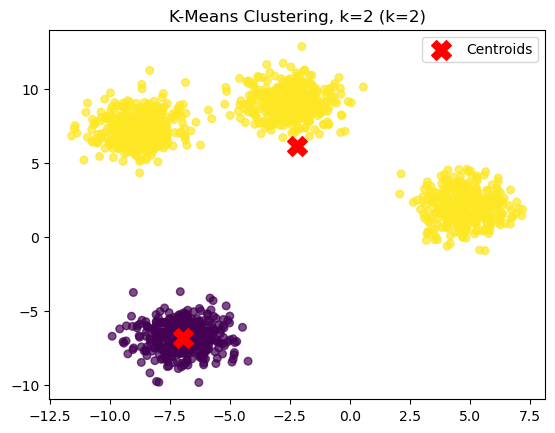

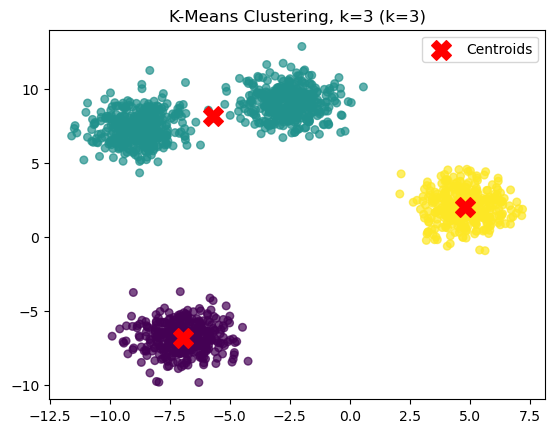

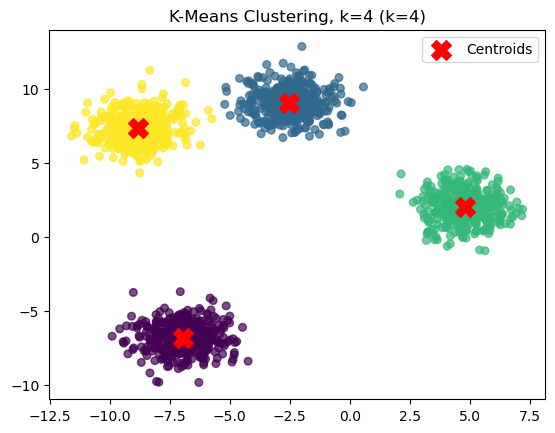

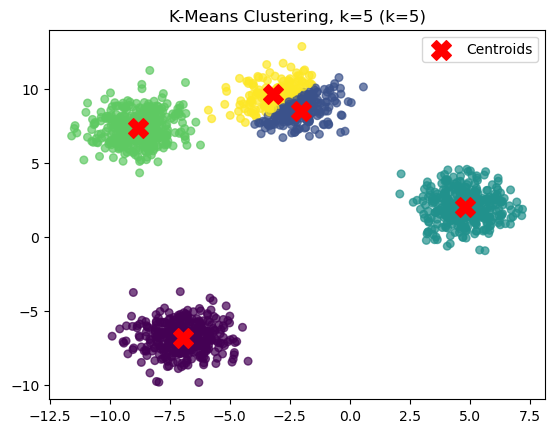

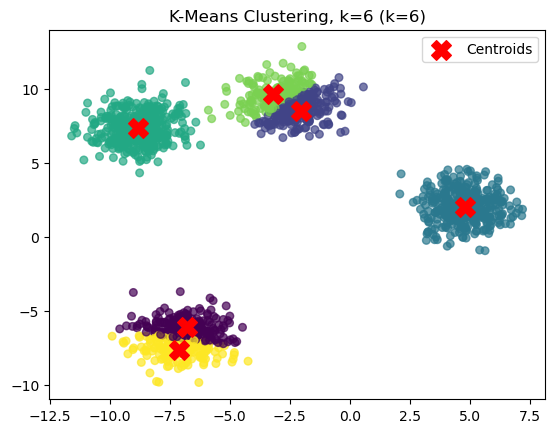

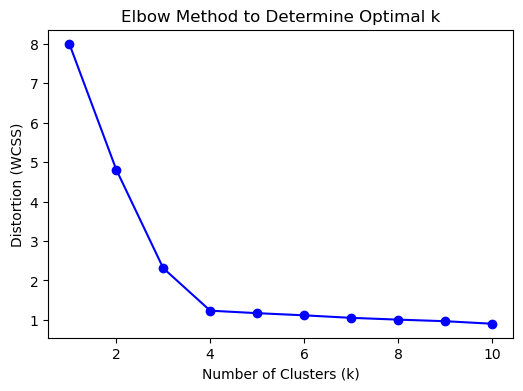

In [12]:
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
# Load dataset
X, y = make_blobs(n_samples=1500, centers=4, random_state=42)

# Function to plot K-Means results
def plot_kmeans(X, n_clusters, title):
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
    y_pred = kmeans.fit_predict(X)

    plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=30, alpha=0.7)
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
                c='red', marker='X', s=200, label='Centroids')
    
    plt.title(f"{title} (k={n_clusters})")
    plt.legend()
    plt.show()

# ** Plot K-Means for different k values**
for k in range(2, 7):  
    plot_kmeans(X, n_clusters=k, title=f"K-Means Clustering, k={k}")

# ** Find optimal k using the Elbow method**
distortions = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X)
    distortions.append(sum(np.min(cdist(X, kmeans.cluster_centers_, 'euclidean'), axis=1)) / X.shape[0])

# Plot Elbow method
plt.figure(figsize=(6,4))
plt.plot(K_range, distortions, marker='o', linestyle='-', color='b')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Distortion (WCSS)")
plt.title("Elbow Method to Determine Optimal k")
plt.show()

## Exercise 3
Perform ```DBSCAN``` clustering on any of the data sets: https://scikit-learn.org/stable/modules/clustering.html#dbscan
* 3.1 Plot the results

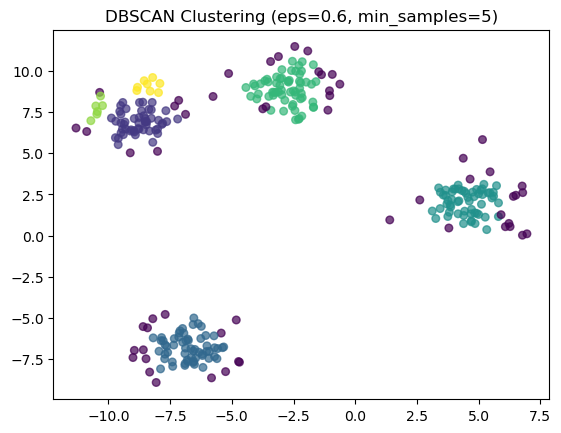

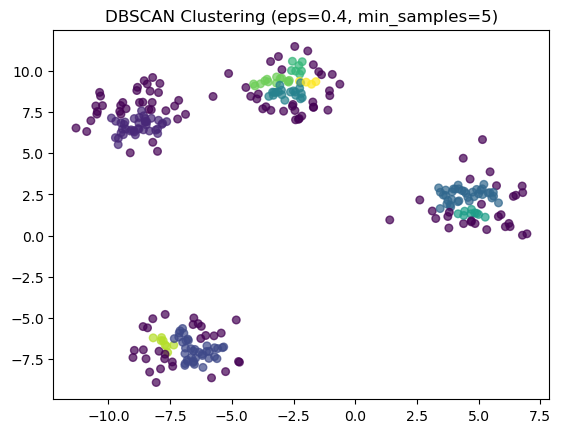

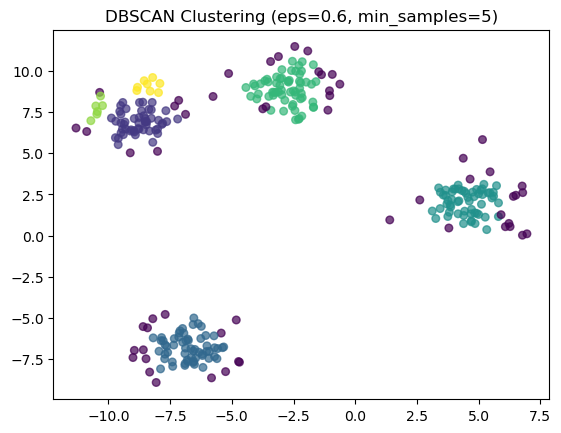

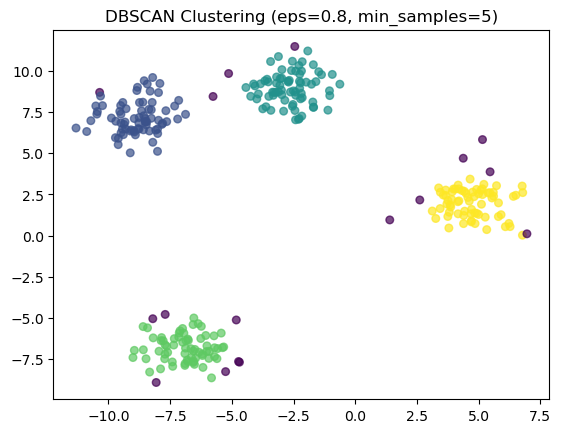

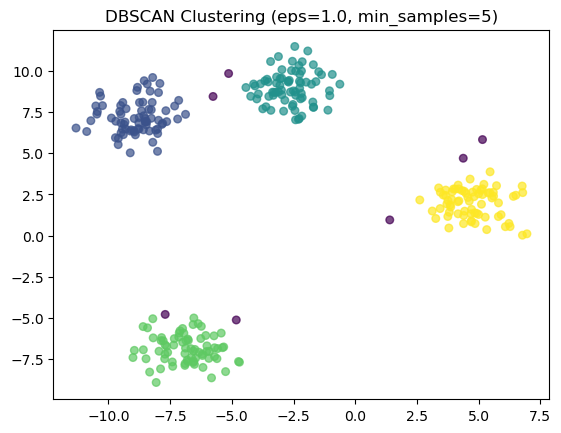

In [13]:
#Load any dataset
X, y = make_blobs(n_samples=300, centers=4, random_state=42)

# Function to plot clustering results
def plot_clustering(X, labels, title):
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30, alpha=0.7)
    plt.title(title)
    plt.show()

# ** Perform DBSCAN clustering with adjusted parameters**
# DBSCAN: The best 'eps' value depends on the scale of the data and expected density of clusters.
# Here, try eps=0.5 and min_samples=5, adjust if needed based on the dataset.

dbscan = DBSCAN(eps=0.6, min_samples=5)  # Tweaking eps for better separation
dbscan_labels = dbscan.fit_predict(X)

plot_clustering(X, dbscan_labels, f"DBSCAN Clustering (eps=0.6, min_samples=5)")

# **2️⃣ Adjust DBSCAN parameters further:**
# Try different eps values, plot results to see how DBSCAN performs with various eps values.
for eps in [0.4, 0.6, 0.8, 1.0]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    dbscan_labels = dbscan.fit_predict(X)
    plot_clustering(X, dbscan_labels, f"DBSCAN Clustering (eps={eps}, min_samples=5)")

## Exercise 4
Compare the results of both above clustering methods by the mean ```Silhouette Coefficient``` for each data set.

Hint: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html#sklearn.metrics.silhouette_score

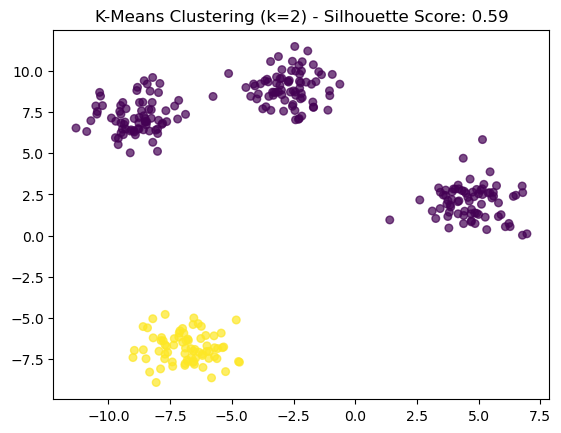

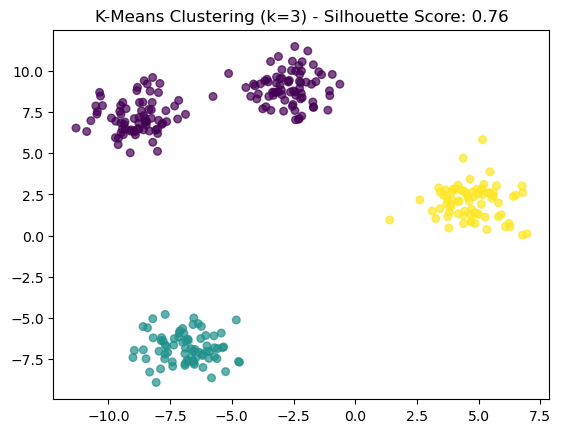

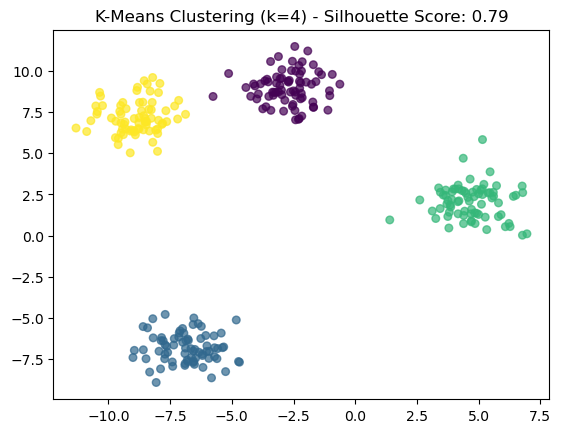

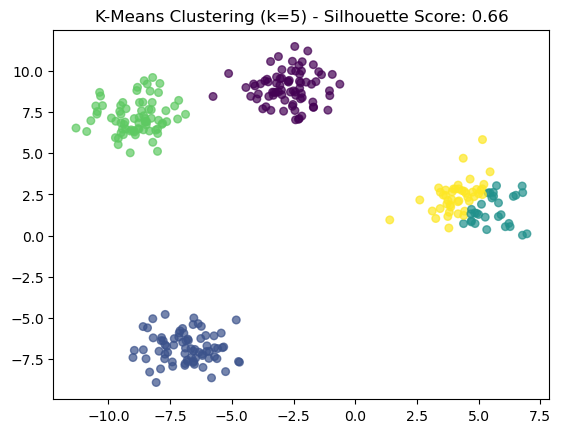

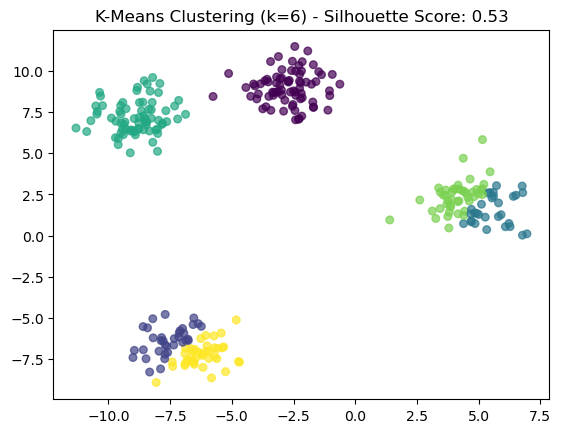

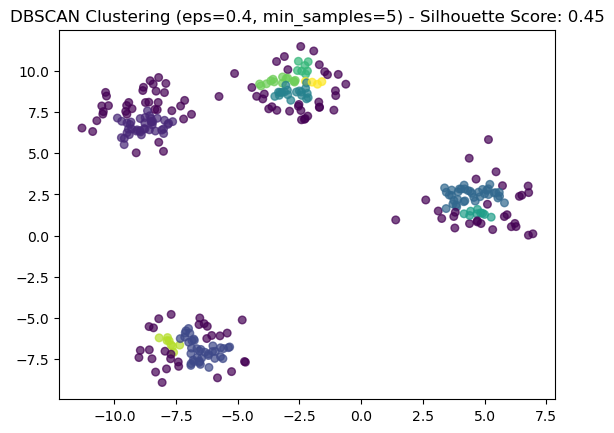

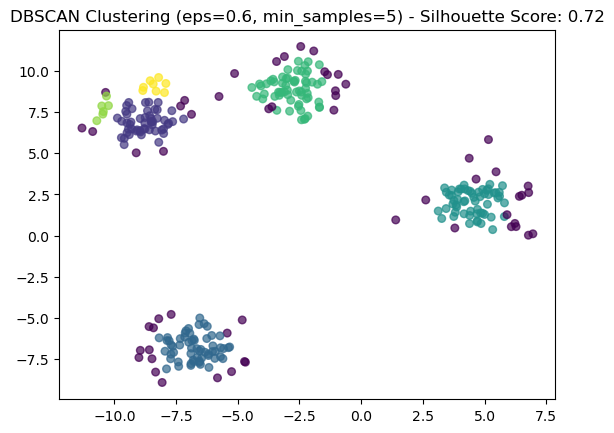

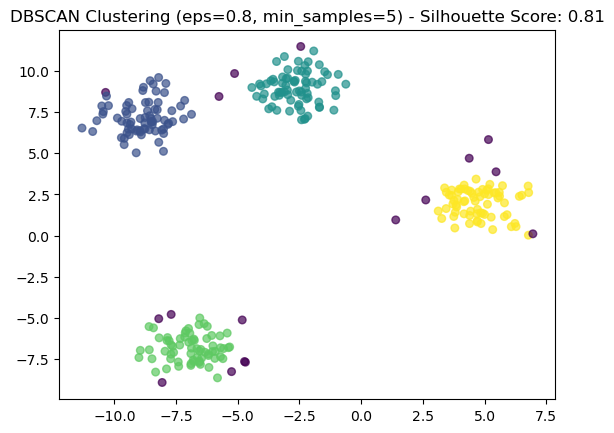

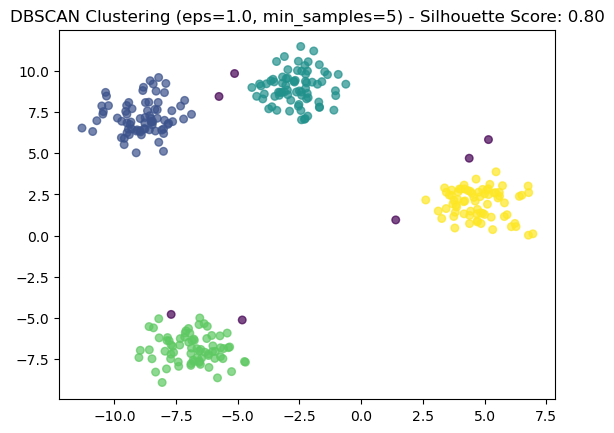

Silhouette Scores for K-Means:
k=2: 0.59
k=3: 0.76
k=4: 0.79
k=5: 0.66
k=6: 0.53

Silhouette Score for DBSCAN: 0.80
DBSCAN:0.45
DBSCAN:0.72
DBSCAN:0.81
DBSCAN:0.80


In [14]:
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
X, y = make_blobs(n_samples=300, centers=4, random_state=42)

# Function to plot clustering results
def plot_clustering(X, labels, title):
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30, alpha=0.7)
    plt.title(title)
    plt.show()
    
silhouette_scores_kmeans = []
silhouette_scores_dbscan = []
# **K-Means Clustering**
for k in range(2, 7):  # Try different k values
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    y_pred = kmeans.fit_predict(X)
    score = silhouette_score(X, y_pred)
    silhouette_scores_kmeans.append(score)
    plot_clustering(X, y_pred, f"K-Means Clustering (k={k}) - Silhouette Score: {score:.2f}")

# **DBSCAN Clustering**
for eps in [0.4, 0.6, 0.8, 1.0]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    dbscan_labels = dbscan.fit_predict(X)

    # DBSCAN may assign noise points (-1), so exclude them for silhouette calculation
    dbscan_labels_cleaned = dbscan_labels[dbscan_labels != -1]
    X_cleaned = X[dbscan_labels != -1]
    dbscan_score = silhouette_score(X_cleaned, dbscan_labels_cleaned)
    silhouette_scores_dbscan.append(dbscan_score)
    plot_clustering(X, dbscan_labels, f"DBSCAN Clustering (eps={eps}, min_samples=5) - Silhouette Score: {dbscan_score:.2f}")

# **3️⃣ Compare Silhouette Scores**
print("Silhouette Scores for K-Means:")
for k, score in zip(range(2, 7), silhouette_scores_kmeans):
    print(f"k={k}: {score:.2f}")

print(f"\nSilhouette Score for DBSCAN: {dbscan_score:.2f}")
for k, score in zip(range(len([0.4, 0.6, 0.8, 1.0])), silhouette_scores_dbscan):
    print(f"DBSCAN:{score:.2f}")


## Optional Task
Perform ```SpectralClustering``` clustering on any data sets:https://scikit-learn.org/stable/modules/clustering.html#spectral-clustering
* Plot the results

# Complete solution for the clustering exercise

This notebook contains a full reference implementation for:
- plotting all raw datasets A-F
- K-Means clustering with K-Means++ and the elbow method
- DBSCAN clustering
- silhouette-score comparison
- optional Spectral Clustering


## Complete reference solution

This final section contains a complete, runnable solution for the clustering exercise, including the optional Spectral Clustering task.


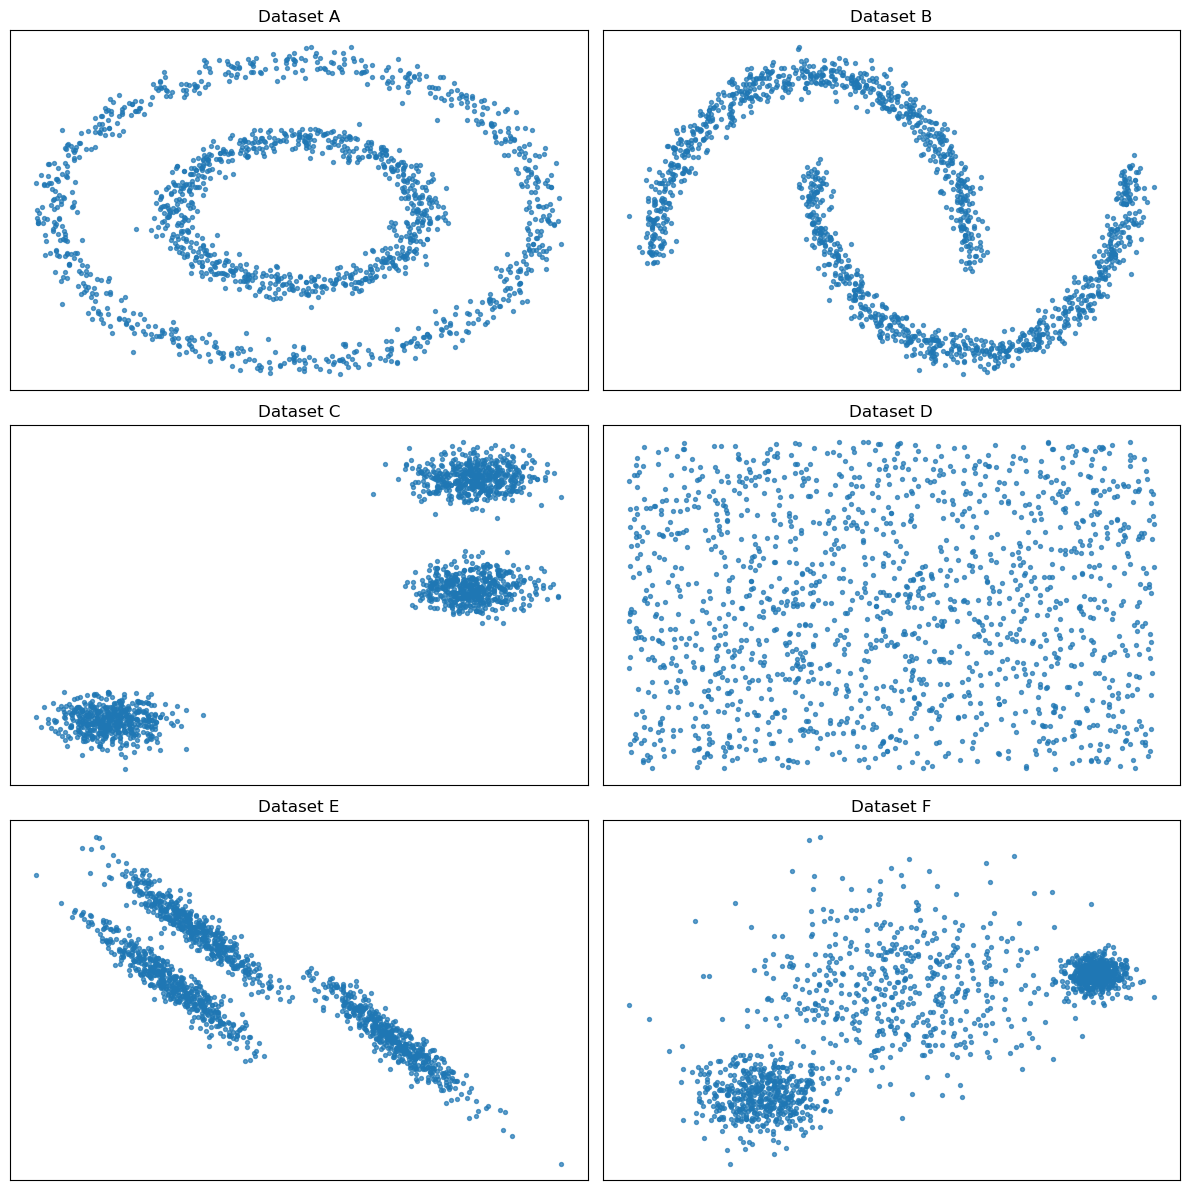


Dataset A: silhouette scores by k -> {2: 0.35256221794072995, 3: 0.39004827449915064, 4: 0.3806971032950809, 5: 0.3583941535117601, 6: 0.33626434688739615}
Best k by silhouette score: 3


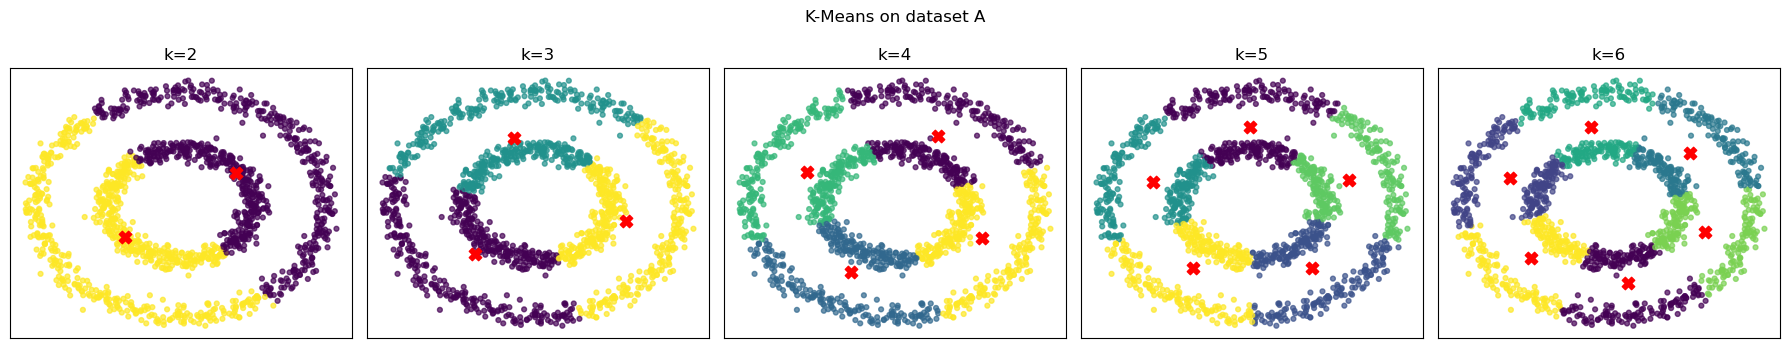


Dataset B: silhouette scores by k -> {2: 0.4914569356774086, 3: 0.4267348661866272, 4: 0.45969703455266303, 5: 0.48798298092827824, 6: 0.5126773071373161}
Best k by silhouette score: 6


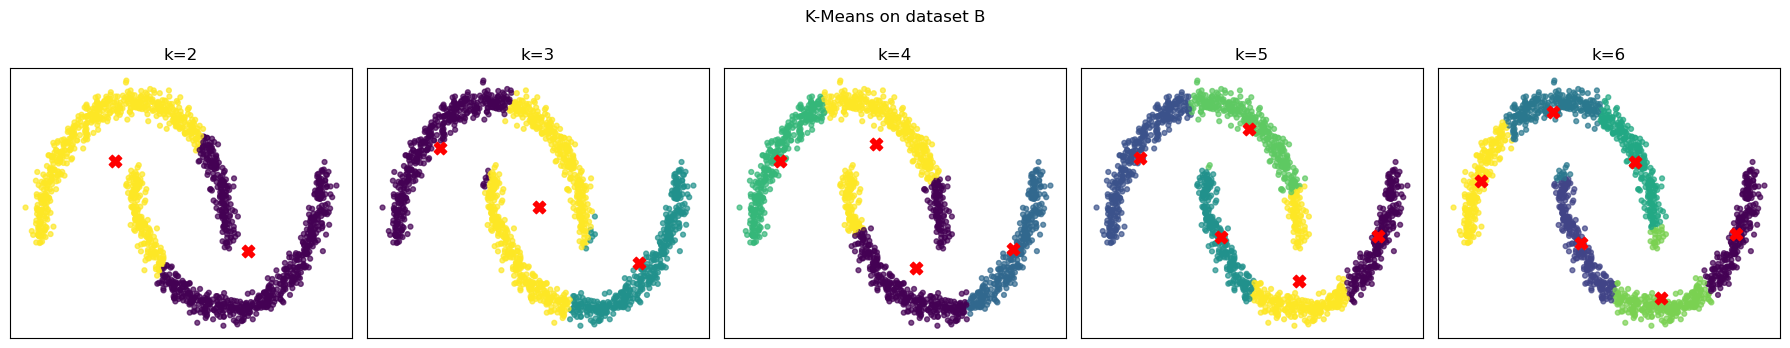


Dataset C: silhouette scores by k -> {2: 0.786262052469124, 3: 0.8290743874701529, 4: 0.6669678611977946, 5: 0.5122049066875457, 6: 0.31869269387480803}
Best k by silhouette score: 3


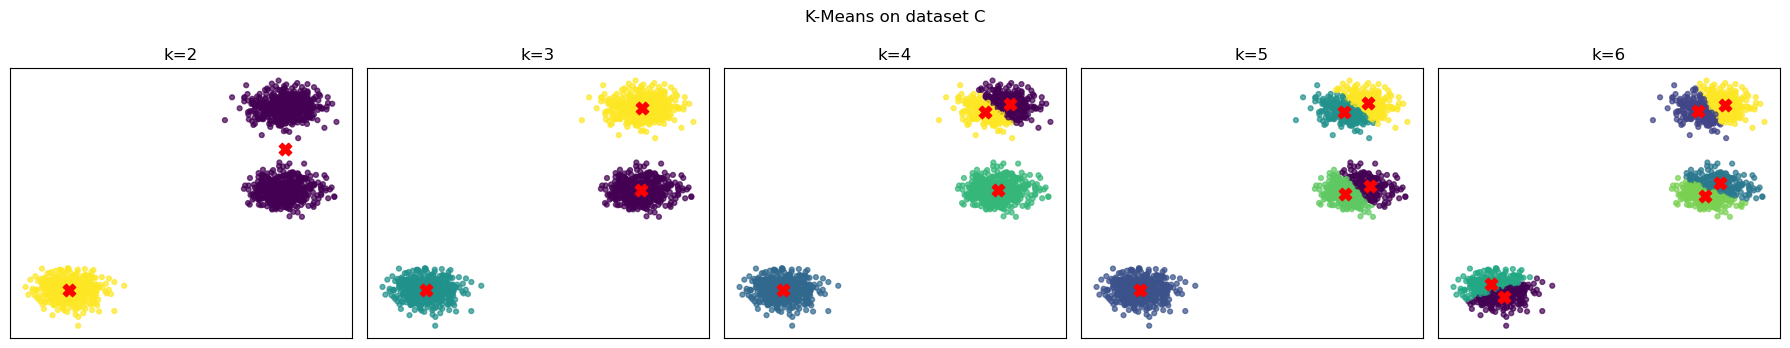


Dataset D: silhouette scores by k -> {2: 0.35302836352155886, 3: 0.378294339678293, 4: 0.3991527722394245, 5: 0.39152875984304886, 6: 0.37366830986864186}
Best k by silhouette score: 4


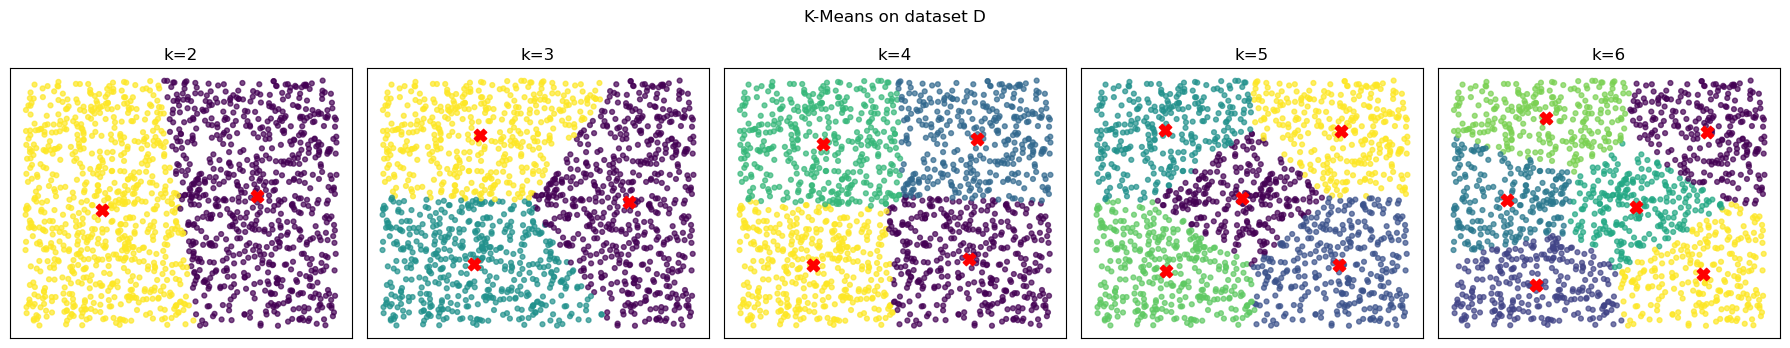


Dataset E: silhouette scores by k -> {2: 0.6355080258146786, 3: 0.5090693051040507, 4: 0.45411872411959153, 5: 0.419036854784658, 6: 0.47164616302240164}
Best k by silhouette score: 2


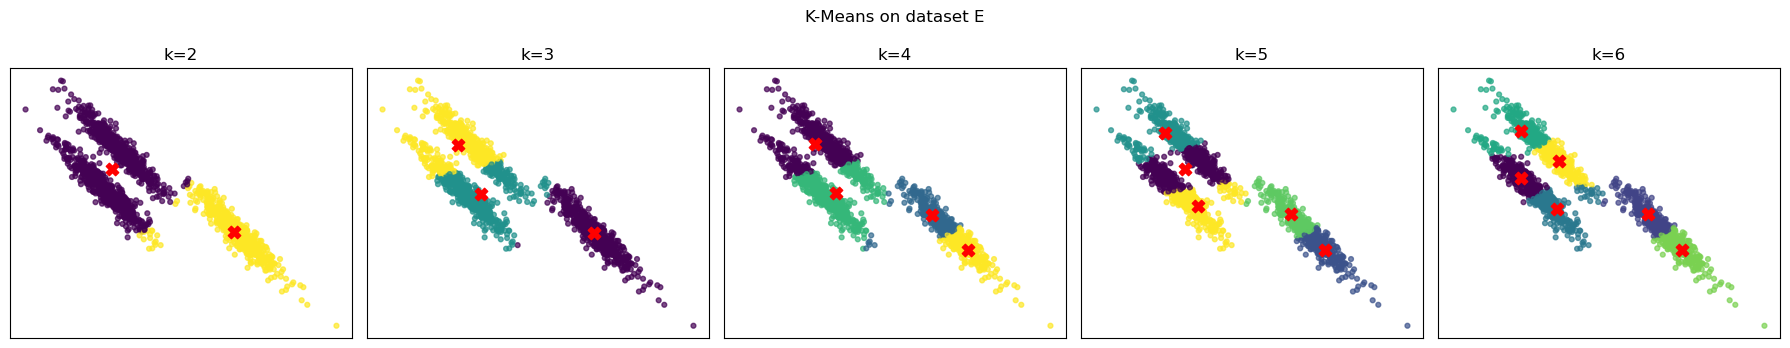


Dataset F: silhouette scores by k -> {2: 0.6174462864467585, 3: 0.646798946148098, 4: 0.6227071527770012, 5: 0.6202488205777319, 6: 0.6074893870256007}
Best k by silhouette score: 3


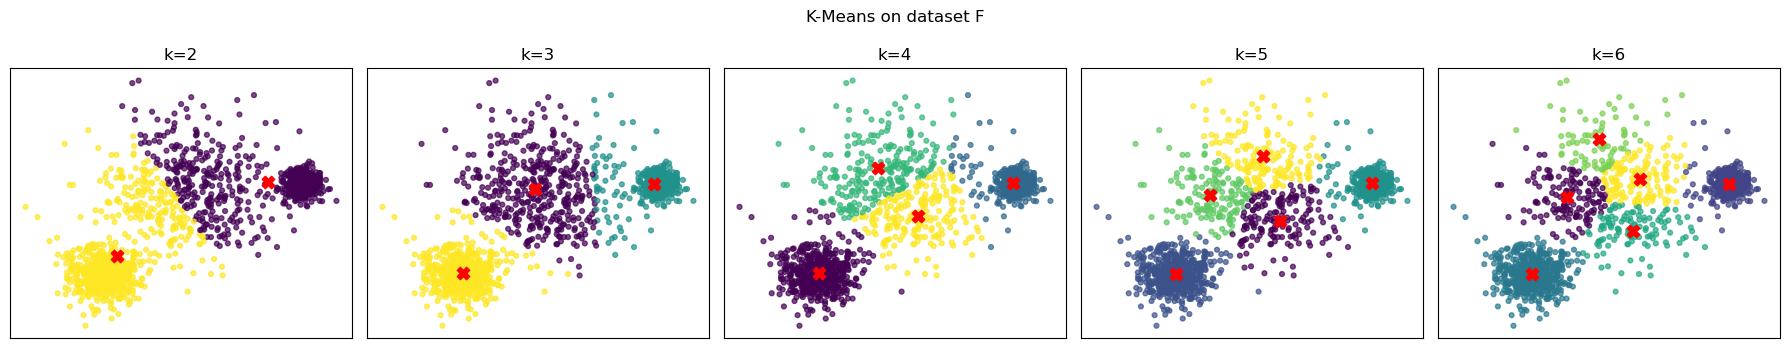

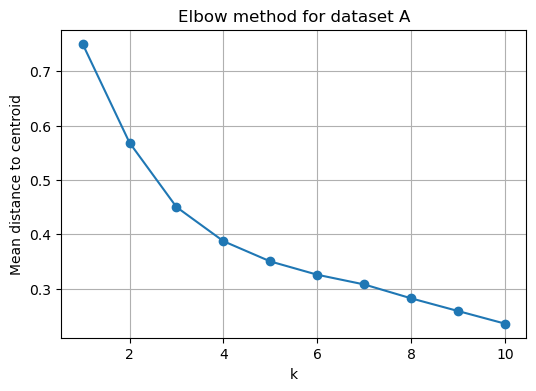

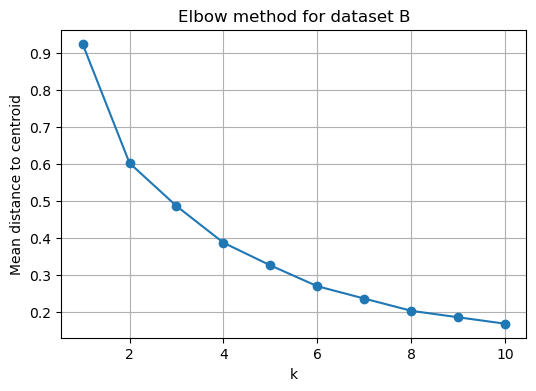

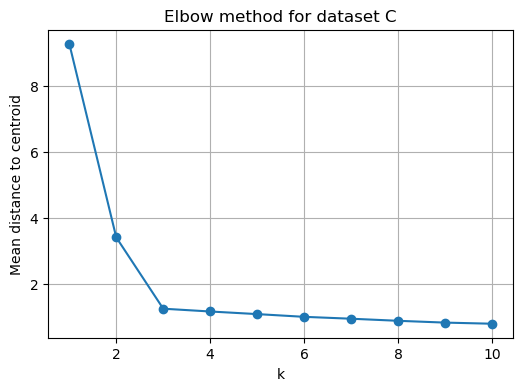

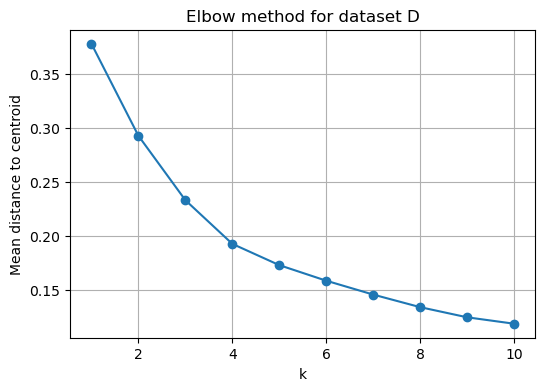

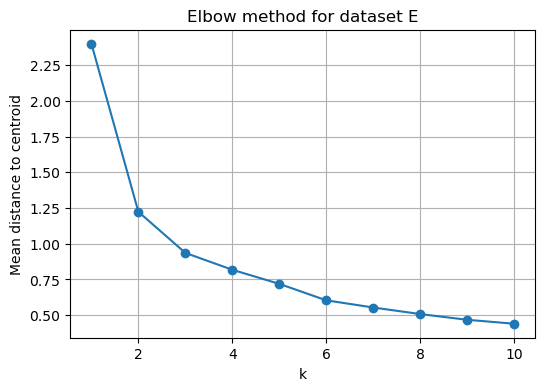

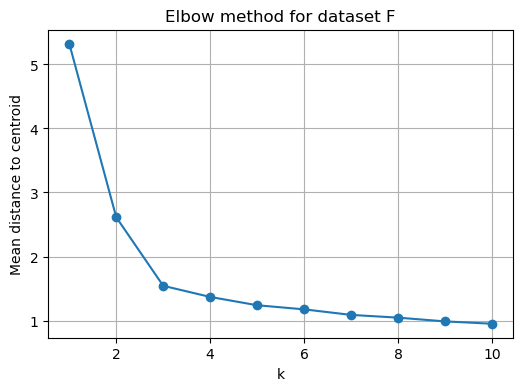


Dataset A: DBSCAN eps=0.12, min_samples=10, silhouette=0.11391370454661717


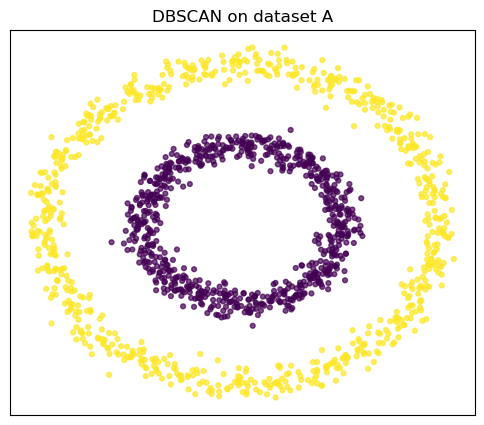


Dataset B: DBSCAN eps=0.18, min_samples=10, silhouette=0.3349491705316322


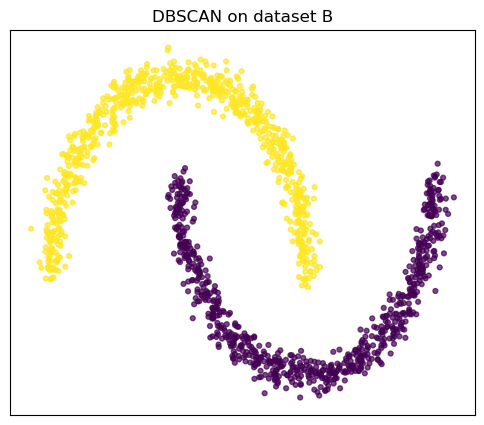


Dataset C: DBSCAN eps=0.2, min_samples=10, silhouette=0.27918878840151257


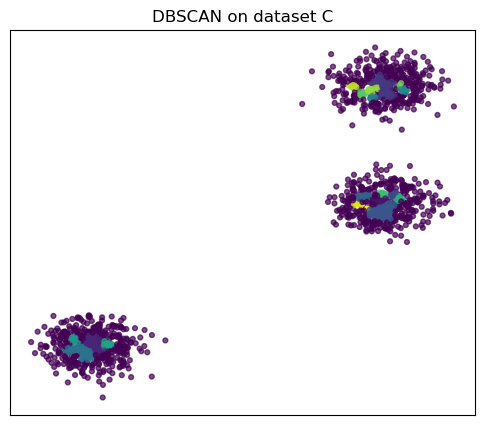


Dataset D: DBSCAN eps=0.12, min_samples=5, silhouette=nan


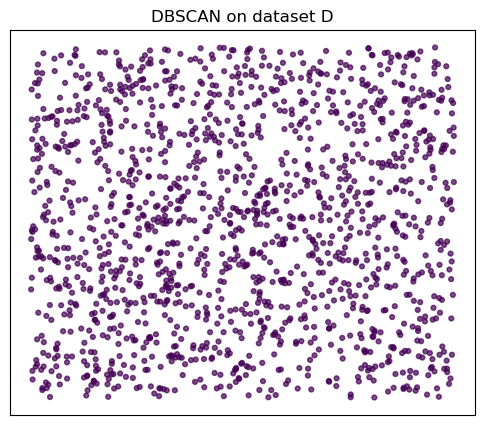


Dataset E: DBSCAN eps=0.15, min_samples=10, silhouette=0.328607600733366


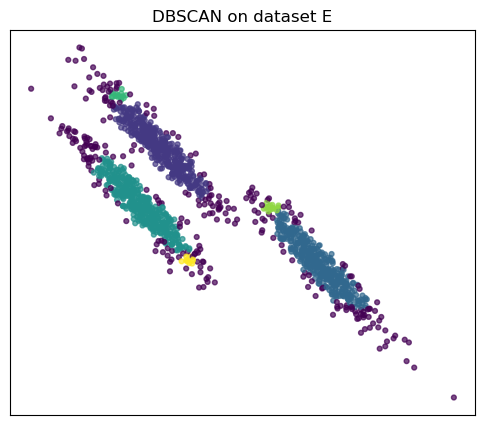


Dataset F: DBSCAN eps=0.25, min_samples=10, silhouette=0.5935454783640671


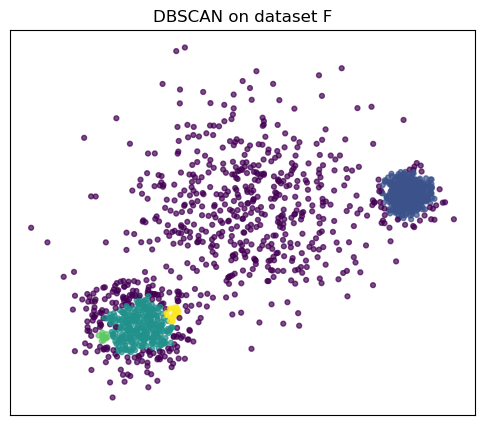


Silhouette comparison summary:

A: KMeans best k=3, silhouette=0.3900; DBSCAN silhouette=0.1139
B: KMeans best k=6, silhouette=0.5127; DBSCAN silhouette=0.3349
C: KMeans best k=3, silhouette=0.8291; DBSCAN silhouette=0.2792
D: KMeans best k=4, silhouette=0.3992; DBSCAN silhouette=nan
E: KMeans best k=2, silhouette=0.6355; DBSCAN silhouette=0.3286
F: KMeans best k=3, silhouette=0.6468; DBSCAN silhouette=0.5935


/home/tmedi/miniconda3/envs/tilo_env/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


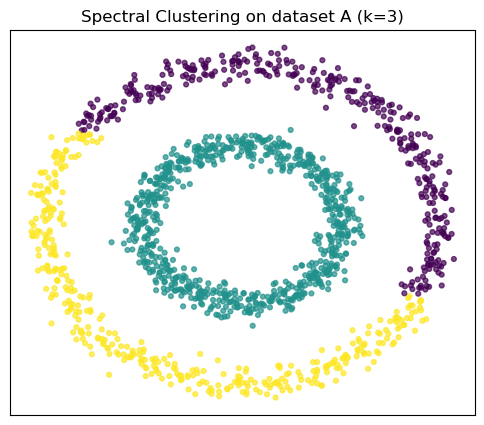

/home/tmedi/miniconda3/envs/tilo_env/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


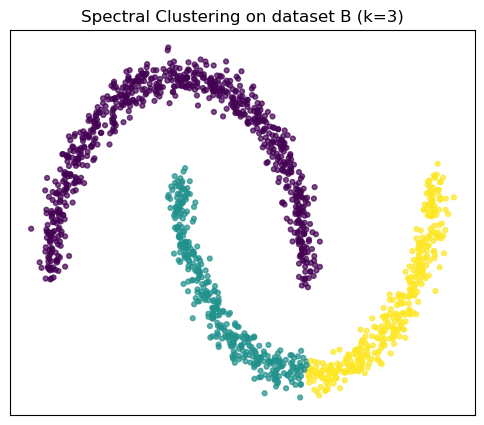

/home/tmedi/miniconda3/envs/tilo_env/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


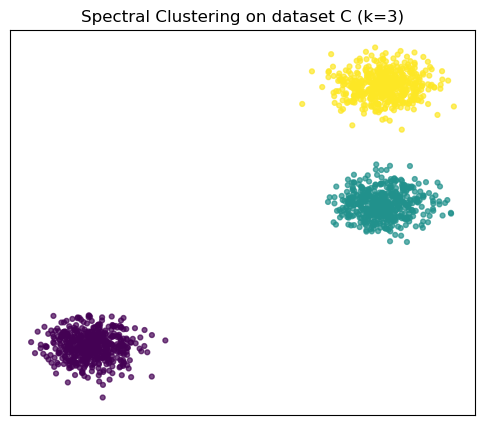

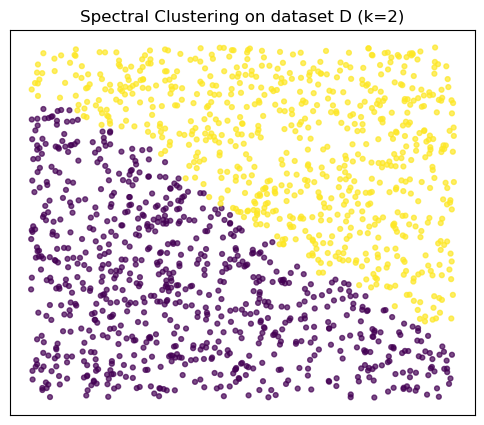

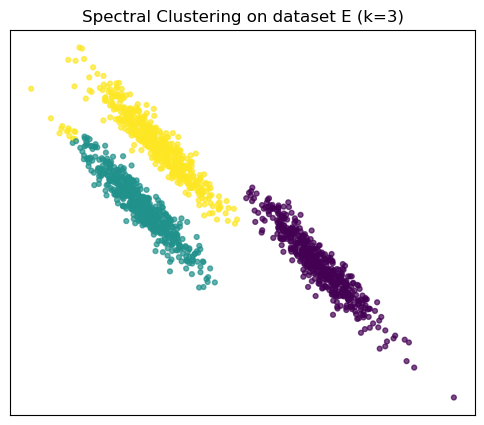

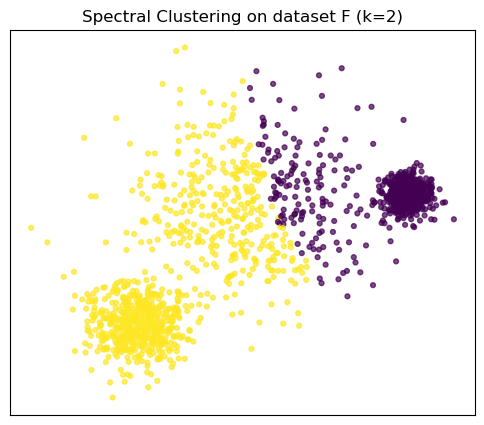


Completed: clustering exercise solution and optional spectral clustering task.


In [15]:
# Complete solution for the clustering exercise
# Includes the optional Spectral Clustering task.

import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

plt.style.use('default')

# -----------------------------
# 1. Generate datasets A-F
# -----------------------------
np.random.seed(170)
n_samples = 1500
X_blobs, y = datasets.make_blobs(n_samples=n_samples, random_state=170)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X_blobs, transformation)

A = datasets.make_circles(n_samples=n_samples, factor=.5, noise=.05)[0]
B = datasets.make_moons(n_samples=n_samples, noise=.05)[0]
C = datasets.make_blobs(n_samples=n_samples, random_state=8)[0]
D = np.random.rand(n_samples, 2)
E = X_aniso
F = datasets.make_blobs(n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=170)[0]

DATASETS = {'A': A, 'B': B, 'C': C, 'D': D, 'E': E, 'F': F}

# -----------------------------
# 2. Plot all raw datasets A-F
# -----------------------------
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, (name, X) in zip(axes, DATASETS.items()):
    ax.scatter(X[:, 0], X[:, 1], s=8, alpha=0.7)
    ax.set_title(f'Dataset {name}')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

# -----------------------------
# 3. K-Means with K-Means++
# -----------------------------
def evaluate_kmeans(X, ks=(2, 3, 4, 5, 6), random_state=42):
    scores = {}
    labels_dict = {}
    centers_dict = {}

    for k in ks:
        model = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=random_state)
        labels = model.fit_predict(X)
        unique_labels = np.unique(labels)
        if len(unique_labels) > 1:
            score = silhouette_score(X, labels)
        else:
            score = np.nan
        scores[k] = score
        labels_dict[k] = labels
        centers_dict[k] = model.cluster_centers_

    best_k = max(scores, key=lambda k: scores[k] if np.isfinite(scores[k]) else -np.inf)
    return scores, labels_dict, centers_dict, best_k

for name, X in DATASETS.items():
    scores, labels_dict, centers_dict, best_k = evaluate_kmeans(X)
    print(f'\nDataset {name}: silhouette scores by k -> {scores}')
    print(f'Best k by silhouette score: {best_k}')

    fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
    for ax, k in zip(axes, range(2, 7)):
        labels = labels_dict[k]
        centers = centers_dict[k]
        ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=12, alpha=0.7)
        ax.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=80)
        ax.set_title(f'k={k}')
        ax.set_xticks([])
        ax.set_yticks([])
    plt.suptitle(f'K-Means on dataset {name}')
    plt.tight_layout()
    plt.show()

# -----------------------------
# 4. Elbow method for choosing k
# -----------------------------
for name, X in DATASETS.items():
    distortions = []
    ks = range(1, 11)
    for k in ks:
        model = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
        model.fit(X)
        dist = sum(np.min(cdist(X, model.cluster_centers_, 'euclidean'), axis=1)) / X.shape[0]
        distortions.append(dist)

    plt.figure(figsize=(6, 4))
    plt.plot(list(ks), distortions, marker='o')
    plt.xlabel('k')
    plt.ylabel('Mean distance to centroid')
    plt.title(f'Elbow method for dataset {name}')
    plt.grid(True)
    plt.show()

# -----------------------------
# 5. DBSCAN clustering
# -----------------------------
# Use dataset-specific values to get a reasonable clustering pattern.
DBSCAN_PARAMS = {
    'A': (0.12, 10),
    'B': (0.18, 10),
    'C': (0.2, 10),
    'D': (0.12, 5),
    'E': (0.15, 10),
    'F': (0.25, 10),
}

for name, X in DATASETS.items():
    eps, min_samples = DBSCAN_PARAMS[name]
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X)

    unique_labels = np.unique(labels)
    non_noise = unique_labels[unique_labels != -1]
    if len(non_noise) > 1:
        score = silhouette_score(X[labels != -1], labels[labels != -1])
    else:
        score = np.nan

    print(f'\nDataset {name}: DBSCAN eps={eps}, min_samples={min_samples}, silhouette={score}')

    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=12, alpha=0.7)
    plt.title(f'DBSCAN on dataset {name}')
    plt.xticks([])
    plt.yticks([])
    plt.show()

# -----------------------------
# 6. Compare K-Means and DBSCAN using silhouette score
# -----------------------------
print('\nSilhouette comparison summary:\n')
for name, X in DATASETS.items():
    # K-Means: select best k from 2..6 by silhouette
    scores, _, _, best_k = evaluate_kmeans(X)
    km_model = KMeans(n_clusters=best_k, init='k-means++', n_init=20, random_state=42)
    km_labels = km_model.fit_predict(X)
    km_score = silhouette_score(X, km_labels)

    # DBSCAN
    eps, min_samples = DBSCAN_PARAMS[name]
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    db_labels = dbscan.fit_predict(X)
    mask = db_labels != -1
    db_score = silhouette_score(X[mask], db_labels[mask]) if np.sum(mask) > 0 and len(np.unique(db_labels[mask])) > 1 else np.nan

    print(f'{name}: KMeans best k={best_k}, silhouette={km_score:.4f}; DBSCAN silhouette={db_score:.4f}')

# -----------------------------
# 7. Optional: Spectral Clustering
# -----------------------------
for name, X in DATASETS.items():
    k = 3 if name in {'A', 'B', 'C', 'E'} else 2
    spec = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', random_state=42, n_init=10)
    labels = spec.fit_predict(X)

    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=12, alpha=0.7)
    plt.title(f'Spectral Clustering on dataset {name} (k={k})')
    plt.xticks([])
    plt.yticks([])
    plt.show()

print('\nCompleted: clustering exercise solution and optional spectral clustering task.')
